# Week 38, Tuesday session: adaptive optimisers and stochastic gradient descent in practice

**FYS-STK3155/4155, Tuesday September 15, 2026**

This is the notebook for the flipped session. Monday's lecture covered gradient
descent with and without momentum once more (Sections 4.3–4.6), automatic
differentiation (Section 4.14), the adaptive methods AdaGrad, RMSProp and Adam
(Sections 4.8–4.12) and stochastic gradient descent (Section 4.7). Today, after
your questions, we work through two cases in pairs or small groups:

* **Case 1: AdaGrad, RMSProp and Adam in your own code, on the Runge function.**
  The five optimisers in one step function, iterations to a given accuracy at
  degree 6, a learning-rate scan showing that $\gamma$ means something different
  to each method, and degree 10 with Ridge and with one Newton step. This is
  part f) of Project 1.
* **Case 2: stochastic gradient descent.** The noise of the minibatch gradient,
  minibatches and epochs in the loop, the batch size, constant learning rates
  against the schedule of Eq. (4.40), and Adam with minibatches. This is part h)
  of Project 1.

Each case ends with three or four questions for the plenary. The code from
week 37 (`exercise_data`, `runge_data`, `closed_form`, `gradient`,
`hessian_eigs`) is repeated below; the seed is 2026 throughout, so that your
numbers are the lecture's numbers.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

BLUE, RED, YELLOW, GREY = "#004488", "#BB5566", "#DDAA33", "#777777"
GREEN = "#228833"
np.set_printoptions(precision=4, suppress=True)

In [17]:
def exercise_data(n=100, degree=2, noise=0.5, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2.0, 2.0, n)
    y = 2.0 - x + 5.0 * x**2 + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_mean, X_std = X.mean(axis=0), X.std(axis=0)
    X_norm = (X - X_mean) / X_std
    y_centered = y - y.mean()
    return X_norm, y_centered


def runge_data(n=100, degree=6, noise=0.1, seed=2026):
    """Runge function 1/(1+25x^2) on [-1,1], standardised polynomial features, centred y."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 1.0, n)
    y = 1.0 / (1.0 + 25.0 * x**2) + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()


def closed_form(X, y, lam=0.0):
    """Eq. (3.44) with the 1/n convention of Eq. (3.95): (X^T X + n lambda I)^-1 X^T y."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)


def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16): (1/n)||X theta - y||^2 + lambda theta^T theta."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta


def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta


def hessian_eigs(X, lam=0.0):
    """Eigenvalues of the Hessian (2/n) X^T X + 2 lambda I, Eqs. (4.14) and (4.17)."""
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))


## Case 1: AdaGrad, RMSProp and Adam on the Runge function

### Step 1: the problem, and why it is hard

$f(x) = 1/(1+25x^2)$ on $[-1, 1]$, $n = 100$, noise $0.1$, polynomial features of
degree 6 and 10, standardised columns, centred $\boldsymbol{y}$. Compute the
eigenvalues of the Hessian, $\kappa$, and the largest stable learning rate for
plain gradient descent for both degrees.

In [18]:
for degree in (6, 10):
    X, y = runge_data(degree=degree)
    eigs = hessian_eigs(X)
    print(f"degree {degree:2d}: lambda_max = {eigs.max():.3f}, lambda_min = {eigs.min():.2e}, "
          f"kappa = {eigs.max() / eigs.min():.2e}, gamma_max = 2/lambda_max = {2 / eigs.max():.3f}")

degree  6: lambda_max = 5.995, lambda_min = 3.24e-03, kappa = 1.85e+03, gamma_max = 2/lambda_max = 0.334
degree 10: lambda_max = 9.973, lambda_min = 5.02e-06, kappa = 1.99e+06, gamma_max = 2/lambda_max = 0.201


### Step 2: one step function for five optimisers

Fill in `optimiser_step` from Eqs. (4.10), (4.28), (4.42)–(4.45), (4.47)–(4.48)
and (4.51)–(4.55). Keep the three-function structure of week 37: the gradient
comes from `gradient` (or from `jax.grad`, Case 2 of week 37 — the step function
does not care), the step function updates $\boldsymbol{\theta}$ and a dictionary
`state` of running quantities, and `optimise` runs the loop. Only Adam needs the
step counter $t$, for the bias correction of Eq. (4.54).

In [19]:
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t (t = 1, 2, ...), Eqs. (4.10), (4.28),
    (4.42)-(4.45), (4.47)-(4.48) and (4.51)-(4.55).  state carries the running quantities."""
    if method == "plain":
        return theta - gamma * g, state
    if method == "momentum":
        v = beta * state.get("v", 0.0) + gamma * g               # Eq. (4.28)
        state["v"] = v
        return theta - v, state
    if method == "adagrad":
        r = state.get("r", 0.0) + g * g                           # Eq. (4.42)
        state["r"] = r
        return theta - gamma * g / (np.sqrt(r) + eps), state      # Eq. (4.45)
    if method == "rmsprop":
        r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g       # Eq. (4.47)
        state["r"] = r
        return theta - gamma * g / (np.sqrt(r) + eps), state      # Eq. (4.48)
    if method == "adam":
        m = beta1 * state.get("m", 0.0) + (1.0 - beta1) * g       # Eq. (4.51)
        r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g   # Eq. (4.52)
        state["m"], state["r"] = m, r
        m_hat = m / (1.0 - beta1**t)                              # Eq. (4.54)
        r_hat = r / (1.0 - beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state   # Eq. (4.55)
    raise ValueError(f"unknown method {method}")


def optimise(grad, theta0, method, gamma, num_iters=1000, tol=0.0, **kw):
    """Run one optimiser from theta0 with the full gradient; returns all iterates."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history)


### Step 3: degree 6 — iterations to a fixed excess cost

Run all five from $\boldsymbol{\theta}_0 = \boldsymbol{0}$ on the degree-6
problem and record the excess cost $C(\boldsymbol{\theta}_k) - C(\hat{\boldsymbol{\theta}}_{\mathrm{OLS}})$
against the iteration. Plain descent and momentum at $\gamma = 0.9 \cdot 2/\lambda_{\max}$;
AdaGrad at $\gamma = 0.5$, RMSProp at $0.01$, Adam at $0.05$. How many
iterations to $10^{-8}$? Which method never gets there, and why?

In [20]:
RUNGE_RUNS = (('plain', None, '#777777', 'plain GD'), ('momentum', None, '#004488', 'momentum, $\\beta=0.9$'), ('adagrad', 0.5, '#DDAA33', 'AdaGrad, $\\gamma=0.5$'), ('rmsprop', 0.01, '#228833', 'RMSProp, $\\gamma=0.01$'), ('adam', 0.05, '#BB5566', 'Adam, $\\gamma=0.05$'))

def runge_comparison(degree=10, num_iters=30000):
    """Excess cost C(theta_k) - C(theta_hat) for the five optimisers on the Runge problem."""
    X, y = runge_data(degree=degree)
    theta_cf = closed_form(X, y)
    c_min = cost(theta_cf, X, y)
    eigs = hessian_eigs(X)
    gamma_gd = 0.9 * 2.0 / eigs.max()
    grad = lambda th: gradient(th, X, y)
    out = {}
    for method, gamma, _, _ in RUNGE_RUNS:
        g = gamma_gd if gamma is None else gamma
        path = optimise(grad, np.zeros(degree), method, g, num_iters=num_iters)
        out[method] = np.array([cost(th, X, y) - c_min for th in path])
    return out, eigs, gamma_gd


In [21]:
excess6, eigs6, gamma6 = runge_comparison(degree=6, num_iters=20000)
for method, gamma, _, _ in RUNGE_RUNS:
    e = excess6[method]
    first = {tol: (int(np.argmax(e < tol)) if (e < tol).any() else None) for tol in (1e-4, 1e-8)}
    print(f"{method:8s} (gamma = {gamma6 if gamma is None else gamma:.3f}): to 1e-4: {first[1e-4]}, to 1e-8: {first[1e-8]}, "
          f"after 20000: {max(e[-1], 0):.1e}")

plain    (gamma = 0.300): to 1e-4: 2617, to 1e-8: 7346, after 20000: 0.0e+00
momentum (gamma = 0.300): to 1e-4: 246, to 1e-8: 670, after 20000: 0.0e+00
adagrad  (gamma = 0.500): to 1e-4: 4333, to 1e-8: 12156, after 20000: 9.8e-13
rmsprop  (gamma = 0.010): to 1e-4: None, to 1e-8: None, after 20000: 4.5e-04
adam     (gamma = 0.050): to 1e-4: 574, to 1e-8: 1062, after 20000: 4.9e-16


### Step 4: the learning-rate scan — $\gamma$ is not the same number for every method

For each method, scan $\gamma$ over a logarithmic grid from $10^{-3}$ to $1$ and
record the iterations to an excess cost of $10^{-6}$ (or `None`). Where is each
method's window of usable $\gamma$, and where is its best value? Compare with
$2/\lambda_{\max} = 0.334$ and, for momentum, $2(1+\beta)/\lambda_{\max} = 0.63$.

In [22]:
X6, y6 = runge_data(degree=6)
theta6 = closed_form(X6, y6)
c6 = cost(theta6, X6, y6)
grad6 = lambda th: gradient(th, X6, y6)
gammas = np.geomspace(1e-3, 1.0, 16)
np.seterr(over="ignore", invalid="ignore")   # diverging runs overflow; that is the answer, not an error
print("gamma grid:", np.round(gammas, 4))
scan = {}
for method in ("plain", "momentum", "adagrad", "rmsprop", "adam"):
    its = []
    for g in gammas:
        path = optimise(grad6, np.zeros(6), method, g, num_iters=20000)
        e = np.array([cost(p, X6, y6) - c6 for p in path[::10]])
        its.append(int(np.argmax(e < 1e-6)) * 10 if (e < 1e-6).any() else None)
    scan[method] = its
    ok = [(gammas[i], its[i]) for i in range(len(its)) if its[i] is not None]
    best = min(ok, key=lambda t: t[1]) if ok else None
    print(f"{method:8s}: usable gamma from {ok[0][0]:.4f} to {ok[-1][0]:.4f}" if ok else f"{method:8s}: never reaches 1e-6",
          f"; best {best[1]} iterations at gamma = {best[0]:.3f}" if best else "")

gamma grid: [0.001  0.0016 0.0025 0.004  0.0063 0.01   0.0158 0.0251 0.0398 0.0631
 0.1    0.1585 0.2512 0.3981 0.631  1.    ]
plain   : usable gamma from 0.1000 to 0.2512 ; best 5960 iterations at gamma = 0.251
momentum: usable gamma from 0.0100 to 0.6310 ; best 200 iterations at gamma = 0.631
adagrad : usable gamma from 0.0398 to 1.0000 ; best 7390 iterations at gamma = 0.158
rmsprop : never reaches 1e-6 
adam    : usable gamma from 0.0010 to 1.0000 ; best 590 iterations at gamma = 0.100


plain   : usable gamma from 0.1000 to 0.2512 ; best 5960 iterations at gamma = 0.251


momentum: usable gamma from 0.0100 to 0.6310 ; best 200 iterations at gamma = 0.631


adagrad : usable gamma from 0.0398 to 1.0000 ; best 7390 iterations at gamma = 0.158


rmsprop : never reaches 1e-6 


adam    : usable gamma from 0.0010 to 1.0000 ; best 590 iterations at gamma = 0.100


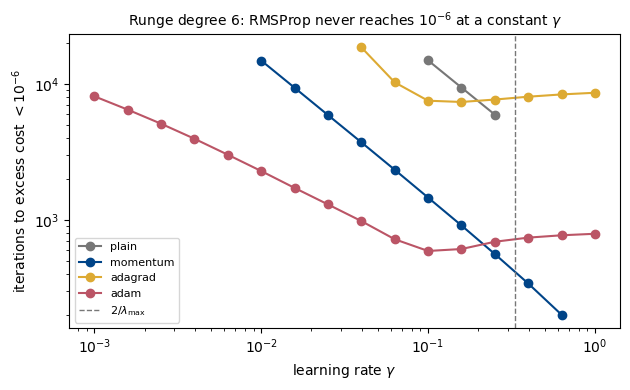

In [23]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))
for method, col in (("plain", GREY), ("momentum", BLUE), ("adagrad", YELLOW), ("adam", RED)):
    its = np.array([np.nan if k is None else k for k in scan[method]])
    ax.loglog(gammas, its, "o-", color=col, label=method)
ax.axvline(2 / eigs6.max(), color=GREY, ls="--", lw=1, label=r"$2/\lambda_{\max}$")
ax.set_xlabel(r"learning rate $\gamma$"); ax.set_ylabel(r"iterations to excess cost $<10^{-6}$")
ax.set_title("Runge degree 6: RMSProp never reaches $10^{-6}$ at a constant $\\gamma$", fontsize=10)
ax.legend(fontsize=8); fig.tight_layout()
plt.show()

### Step 5: degree 10, Ridge, and one Newton step

Now degree 10, $\kappa = 2 \times 10^6$. Run momentum and Adam for 30 000
iterations: what excess cost do they reach? Then Ridge with $\lambda = 10^{-3}$
(what is $\kappa$ now?), and finally one Newton step with the exact Hessian
$\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$ (or `jax.hessian` of your cost).
Is Ridge cheating?

In [24]:
X10, y10 = runge_data(degree=10)
n10 = len(y10)
for lam in (0.0, 1e-3):
    theta_r = closed_form(X10, y10, lam)
    c_r = cost(theta_r, X10, y10, lam)
    eigs = hessian_eigs(X10, lam)
    for method, gamma in (("momentum", 0.9 * 2 / eigs.max()), ("adam", 0.05)):
        path = optimise(lambda th: gradient(th, X10, y10, lam), np.zeros(10), method, gamma, num_iters=30000)
        e = np.array([cost(th, X10, y10, lam) - c_r for th in path[::10]])
        k = int(np.argmax(e < 1e-8)) * 10 if (e < 1e-8).any() else None
        print(f"lambda = {lam:<6} kappa = {eigs.max() / eigs.min():.2e}: {method:8s} to 1e-8: {k}, after 30000: {max(e[-1], 0):.1e}")
H10 = (2.0 / n10) * X10.T @ X10
theta_newton = np.zeros(10) - np.linalg.solve(H10, gradient(np.zeros(10), X10, y10))
print(f"one Newton step: ||theta - closed form|| = {np.linalg.norm(theta_newton - closed_form(X10, y10)):.1e}")
print("OLS closed form :", closed_form(X10, y10))
print("Ridge 1e-3      :", closed_form(X10, y10, 1e-3))

lambda = 0.0    kappa = 1.99e+06: momentum to 1e-8: None, after 30000: 2.2e-03
lambda = 0.0    kappa = 1.99e+06: adam     to 1e-8: None, after 30000: 1.4e-03
lambda = 0.001  kappa = 4.98e+03: momentum to 1e-8: 1330, after 30000: 0.0e+00
lambda = 0.001  kappa = 4.98e+03: adam     to 1e-8: 1210, after 30000: 3.0e-12
one Newton step: ||theta - closed form|| = 5.9e-10
OLS closed form : [ -0.1146  -3.0908   0.4326  13.4079  -0.6377 -26.5268   0.311   24.3549
   0.0001  -8.4048]
Ridge 1e-3      : [-0.0607 -1.0831  0.1398  1.3308 -0.1404 -0.0764 -0.056  -0.4002  0.103
 -0.0031]


lambda = 0.0    kappa = 1.99e+06: adam     to 1e-8: None, after 30000: 1.4e-03


lambda = 0.001  kappa = 4.98e+03: momentum to 1e-8: 1330, after 30000: 0.0e+00


lambda = 0.001  kappa = 4.98e+03: adam     to 1e-8: 1210, after 30000: 1.3e-15
one Newton step: ||theta - closed form|| = 1.9e-10
OLS closed form : [ -0.1146  -3.0908   0.4326  13.4079  -0.6377 -26.5268   0.311   24.3549
   0.0001  -8.4048]
Ridge 1e-3      : [-0.0607 -1.0831  0.1398  1.3308 -0.1404 -0.0764 -0.056  -0.4002  0.103
 -0.0031]


### Case 1: do you have the insight?

1. Adam converged for *every* learning rate in your scan, from $10^{-3}$ to $1$,
   while plain gradient descent had a window of a factor of three. What makes
   Adam insensitive to $\gamma$ — and does that mean $\gamma$ does not matter for
   Adam?
2. RMSProp at a constant $\gamma$ never reached $10^{-6}$, on a convex quadratic.
   What is its step near the minimum, and what would you change?
3. AdaGrad needed more iterations than plain gradient descent at degree 6.
   Which property of AdaGrad is responsible, and on what kind of problem does
   that same property become an advantage?
4. At degree 10 every first-order method stalled at an excess cost of about
   $10^{-3}$, but Ridge with $\lambda = 10^{-3}$ converged in about a thousand
   iterations and a single Newton step hit the OLS solution. Is Ridge
   cheating? What did Newton use that the other methods did not have?

## Case 2: stochastic gradient descent

### Step 1: the minibatch gradient is a noisy, unbiased estimate

Take last week's degree-2 exercise data ($n = 100$) and the point
$\boldsymbol{\theta} = (0, 3)$. Draw many minibatches of size $M$ and compute the
gradient of the cost on each; compare the mean and the spread of the cloud with
the full gradient for $M = 1, 5, 25$. What does the spread do when $M$ is
quadrupled?

In [25]:
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches (Section 4.7)."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]


In [26]:
X, y = exercise_data(degree=2)
n = len(y)
theta_cf = closed_form(X, y)
theta = np.array([0.0, 3.0])
g_full = gradient(theta, X, y)
rng = np.random.default_rng(2026)
print("full gradient:", g_full)
for M in (1, 5, 25):
    gs = np.array([gradient(theta, X[b], y[b]) for _ in range(40) for b in make_batches(n, M, rng)])
    print(f"M = {M:2d}: mean {np.round(gs.mean(axis=0), 3)}, spread {np.std(gs, axis=0).mean():.3f}")

full gradient: [ 1.4783 -5.4542]
M =  1: mean [ 1.478 -5.454], spread 8.477
M =  5: mean [ 1.478 -5.454], spread 3.697
M = 25: mean [ 1.478 -5.454], spread 1.544


### Step 2: minibatches and epochs in the loop

Write `sgd`: reshuffle the indices every epoch, split them into minibatches,
and for each minibatch compute the gradient on that batch and take a step with
`optimiser_step` — any of the five methods. Return the iterate after every
epoch. Run plain SGD with $M = 5$ at $\gamma = 0.1$ and at $0.02$ for 100
epochs on the degree-2 data and print the distance to the closed-form solution
after 1, 10 and 100 epochs. Does it converge?

In [27]:
def step_length(t, t0, t1):
    """The learning-rate schedule of Eq. (4.40)."""
    return t0 / (t + t1)


def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None,
        lam=0.0, seed=2026, theta0=None, **kw):
    """Minibatch stochastic gradient descent, Eq. (4.34), with any optimiser of optimiser_step.
    schedule=(t0, t1) replaces the constant gamma by Eq. (4.40).  Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta = np.zeros(p) if theta0 is None else np.array(theta0, dtype=float)
    state, t, history = {}, 0, [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch], y[batch], lam)            # Eq. (4.33): the minibatch gradient
            g_t = gamma if schedule is None else step_length(t, *schedule)
            theta, state = optimiser_step(method, theta, g, state, t, g_t, **kw)
        history.append(theta.copy())
    return np.array(history)


In [28]:
for gamma in (0.1, 0.02):
    hist = sgd(X, y, n_epochs=100, batch_size=5, gamma=gamma)
    d = np.linalg.norm(hist - theta_cf, axis=1)
    print(f"M = 5, gamma = {gamma}: distance after 1 / 10 / 100 epochs {d[1]:.1e} / {d[10]:.1e} / {d[100]:.1e}, "
          f"min over the last 50 epochs {d[50:].min():.1e}")

M = 5, gamma = 0.1: distance after 1 / 10 / 100 epochs 8.7e-02 / 6.5e-02 / 4.8e-02, min over the last 50 epochs 1.3e-02
M = 5, gamma = 0.02: distance after 1 / 10 / 100 epochs 2.7e+00 / 1.2e-03 / 7.0e-03, min over the last 50 epochs 2.7e-03


### Step 3: the batch size

Repeat with $M \in \{1, 5, 20, 100\}$ at $\gamma = 0.1$, on the degree-2 data and
then on the degree-5 data ($\kappa = 520$). Count *gradient evaluations*, not
epochs: 100 epochs cost $100n$ single-point gradients whatever $M$ is. Which $M$
wins on each data set — and what happens with $M = 1$ at degree 5, and why?
(Hint: the Hessian of a single-point cost is $2\boldsymbol{x}_i\boldsymbol{x}_i^T$;
what is its largest eigenvalue for the largest $|\boldsymbol{x}_i|$?)

In [29]:
for degree in (2, 5):
    Xd, yd = exercise_data(degree=degree)
    theta_d = closed_form(Xd, yd)
    print(f"degree {degree}, gamma = 0.1, 100 epochs = {100 * len(yd)} single-point gradient evaluations:")
    for M in (1, 5, 20, 100):
        hist = sgd(Xd, yd, n_epochs=100, batch_size=M, gamma=0.1)
        d = np.linalg.norm(hist - theta_d, axis=1)
        print(f"  M = {M:3d}: distance after 10 / 100 epochs {d[10]:.1e} / {d[100]:.1e}")
    xmax = np.max(np.linalg.norm(Xd, axis=1))
    print(f"  largest single-point Hessian eigenvalue 2|x_i|^2 = {2 * xmax**2:.1f}, so gamma must be below {2 / (2 * xmax**2):.3f} for M = 1")

degree 2, gamma = 0.1, 100 epochs = 10000 single-point gradient evaluations:
  M =   1: distance after 10 / 100 epochs 3.3e-01 / 5.3e-02
  M =   5: distance after 10 / 100 epochs 6.5e-02 / 4.8e-02
  M =  20: distance after 10 / 100 epochs 5.6e-03 / 9.0e-03
  M = 100: distance after 10 / 100 epochs 7.5e-01 / 1.8e-08
  largest single-point Hessian eigenvalue 2|x_i|^2 = 20.1, so gamma must be below 0.099 for M = 1
degree 5, gamma = 0.1, 100 epochs = 10000 single-point gradient evaluations:
  M =   1: distance after 10 / 100 epochs 2.1e+10 / 8.9e+96
  M =   5: distance after 10 / 100 epochs 9.2e-01 / 1.3e-01
  M =  20: distance after 10 / 100 epochs 2.9e+00 / 2.1e-01
  M = 100: distance after 10 / 100 epochs 4.0e+00 / 2.0e+00
  largest single-point Hessian eigenvalue 2|x_i|^2 = 85.7, so gamma must be below 0.023 for M = 1


  M =   1: distance after 10 / 100 epochs 2.1e+10 / 8.9e+96
  M =   5: distance after 10 / 100 epochs 9.2e-01 / 1.3e-01
  M =  20: distance after 10 / 100 epochs 2.9e+00 / 2.1e-01
  M = 100: distance after 10 / 100 epochs 4.0e+00 / 2.0e+00
  largest single-point Hessian eigenvalue 2|x_i|^2 = 85.7, so gamma must be below 0.023 for M = 1


### Step 4: a schedule that decays — and one that decays too fast

Replace the constant $\gamma$ by $\gamma_t = t_0/(t + t_1)$, Eq. (4.40). On the
degree-2 data, $(t_0, t_1) = (1, 10)$ starts at $\gamma_0 = 0.1$ and keeps
descending where the constant rate rattled. Now the same pair on the degree-5
data: what happens, and why? Find a pair that works there (try keeping
$t_0/t_1$ fixed and making both larger). Reproduce the lecture figure
`week38_sgd.png` with `fig_sgd` below.

In [30]:
for degree in (2, 5):
    Xd, yd = exercise_data(degree=degree)
    theta_d = closed_form(Xd, yd)
    print(f"degree {degree}:")
    for sched in ((1.0, 10.0), (5.0, 50.0), (20.0, 200.0)):
        hist = sgd(Xd, yd, n_epochs=100, batch_size=5, schedule=sched)
        d = np.linalg.norm(hist - theta_d, axis=1)
        print(f"  t0, t1 = {sched}: gamma_0 = {sched[0] / sched[1]:.2f}, gamma after 100 epochs = {step_length(100 * len(yd) // 5, *sched):.4f}, "
              f"distance after 10 / 100 epochs {d[10]:.1e} / {d[100]:.1e}")

degree 2:
  t0, t1 = (1.0, 10.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0005, distance after 10 / 100 epochs 2.2e-02 / 4.7e-04
  t0, t1 = (5.0, 50.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0024, distance after 10 / 100 epochs 2.3e-03 / 2.2e-04
  t0, t1 = (20.0, 200.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0091, distance after 10 / 100 epochs 2.1e-02 / 2.3e-03
degree 5:
  t0, t1 = (1.0, 10.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0005, distance after 10 / 100 epochs 3.6e+00 / 3.0e+00
  t0, t1 = (5.0, 50.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0024, distance after 10 / 100 epochs 2.4e+00 / 1.1e+00
  t0, t1 = (20.0, 200.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0091, distance after 10 / 100 epochs 1.5e+00 / 2.5e-01


  t0, t1 = (5.0, 50.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0024, distance after 10 / 100 epochs 2.3e-03 / 2.2e-04


  t0, t1 = (20.0, 200.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0091, distance after 10 / 100 epochs 2.1e-02 / 2.3e-03
degree 5:
  t0, t1 = (1.0, 10.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0005, distance after 10 / 100 epochs 3.6e+00 / 3.0e+00
  t0, t1 = (5.0, 50.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0024, distance after 10 / 100 epochs 2.4e+00 / 1.1e+00
  t0, t1 = (20.0, 200.0): gamma_0 = 0.10, gamma after 100 epochs = 0.0091, distance after 10 / 100 epochs 1.5e+00 / 2.5e-01


In [31]:
def fig_sgd(filename="week38_sgd.pdf"):
    X, y = exercise_data(degree=2)
    n = len(y)
    theta_cf = closed_form(X, y)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
    # (a) the cloud of minibatch gradients at one point
    ax = axes[0]
    theta = np.array([0.0, 3.0])
    g_full = gradient(theta, X, y)
    rng = np.random.default_rng(2026)
    for M, col, lab in ((5, YELLOW, "$M=5$"), (25, BLUE, "$M=25$")):
        gs = np.array([gradient(theta, X[b], y[b]) for _ in range(40) for b in make_batches(n, M, rng)])
        ax.scatter(gs[:, 0], gs[:, 1], s=8, color=col, alpha=0.5, label=rf"{lab}: spread {np.std(gs, axis=0).mean():.2f}")
    ax.plot(*g_full, "k*", ms=12, label="full gradient, $M=n=100$")
    ax.set_xlabel(r"$\partial C/\partial\theta_1$"); ax.set_ylabel(r"$\partial C/\partial\theta_2$")
    ax.set_title(r"(a) minibatch gradients at $\boldsymbol{\theta}=(0,3)$: noise $\propto1/\sqrt{M}$", fontsize=10)
    ax.legend(fontsize=8); ax.set_aspect("equal")
    # (b) distance to the minimum against gradient evaluations
    ax = axes[1]
    n_epochs = 100
    evals = np.arange(n_epochs + 1) * n
    for kwargs, col, lab in (
            (dict(batch_size=n, gamma=0.5), GREY, r"full batch, $\gamma=0.5=\gamma^*$"),
            (dict(batch_size=5, gamma=0.1), BLUE, r"SGD, $M=5$, $\gamma=0.1$ constant"),
            (dict(batch_size=5, gamma=0.02), YELLOW, r"SGD, $M=5$, $\gamma=0.02$ constant"),
            (dict(batch_size=5, schedule=(1.0, 10.0)), RED, r"SGD, $M=5$, $\gamma_t=1/(t+10)$, Eq. (4.40)")):
        hist = sgd(X, y, n_epochs=n_epochs, **kwargs)
        ax.semilogy(evals, np.linalg.norm(hist - theta_cf, axis=1), color=col, lw=1.6, label=lab)
    ax.set_xlabel("single-point gradient evaluations ($=$ epochs $\\times\\,n$)")
    ax.set_ylabel(r"$\|\boldsymbol{\theta}-\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\|_2$")
    ax.set_title("(b) degree 2, $n=100$: the same computation, four ways", fontsize=10)
    ax.set_ylim(1e-6, 10); ax.legend(fontsize=7.5, loc="upper right")
    fig.tight_layout(); fig.savefig(filename, bbox_inches="tight"); plt.close(fig)


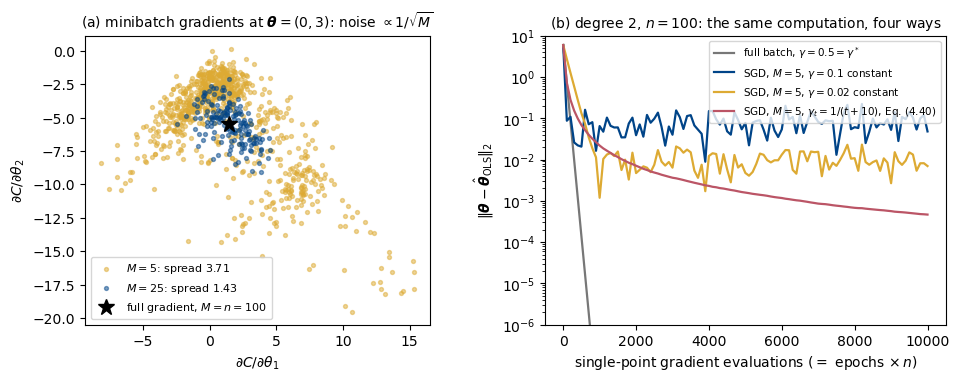

In [32]:
fig_sgd("week38_sgd.png")
Image("week38_sgd.png", width=900)

### Step 5: Adam with minibatches — the default of every framework

Run `sgd` with `method="adam"` on the degree-5 data, $M = 5$, $\gamma \in \{0.01, 0.05\}$,
and compare with plain SGD at $\gamma = 0.1$ and with momentum at $\gamma = 0.05$
after 100 epochs. Which combination gets closest to the closed-form solution?
Which one diverges, and could you have predicted it from Monday's stability
condition for momentum, $\gamma\lambda_{\max} < 2(1+\beta)$, applied to the
single-batch Hessian?

In [33]:
X5, y5 = exercise_data(degree=5)
theta5 = closed_form(X5, y5)
for method, gamma in (("plain", 0.1), ("momentum", 0.05), ("adam", 0.01), ("adam", 0.05), ("rmsprop", 0.01)):
    hist = sgd(X5, y5, n_epochs=100, batch_size=5, gamma=gamma, method=method)
    d = np.linalg.norm(hist - theta5, axis=1)
    print(f"{method:8s} gamma = {gamma}: distance after 10 / 100 epochs {d[10]:.1e} / {d[100]:.1e}")

plain    gamma = 0.1: distance after 10 / 100 epochs 9.2e-01 / 1.3e-01
momentum gamma = 0.05: distance after 10 / 100 epochs 3.0e+02 / 3.5e+19
adam     gamma = 0.01: distance after 10 / 100 epochs 4.8e+00 / 2.9e+00
adam     gamma = 0.05: distance after 10 / 100 epochs 3.7e+00 / 1.4e-01
rmsprop  gamma = 0.01: distance after 10 / 100 epochs 4.4e+00 / 7.5e-01


### Case 2: do you have the insight?

1. Plain SGD with $M = 5$ at a constant $\gamma = 0.1$ sat at a distance of
   $5 \times 10^{-2}$ from the minimum for ninety epochs. Has it converged? What
   is it doing, and what sets the size of the cloud?
2. Full-batch gradient descent ($M = 100$) beat every SGD variant per gradient
   evaluation on the degree-2 data. Is that the general rule? What is different
   about a data set with $n = 10^6$?
3. The schedule $(t_0, t_1) = (1, 10)$ worked on the degree-2 data and froze on
   the degree-5 data. Which of the two Robbins–Monro conditions did it violate
   in practice, and how did you repair it?
4. With $M = 1$ at $\gamma = 0.1$ the degree-5 run diverged although
   $\gamma < 2/\lambda_{\max}$ for the full Hessian. Which Hessian matters for
   a minibatch step?

## Wrap-up

You should now own: a step function with five optimisers and one gradient
(analytical or from `jax.grad`), an `sgd` loop with minibatches, epochs and a
schedule, the habit of scanning the learning rate *per method*, and one
sentence each on what AdaGrad, RMSProp and Adam do to the step, what the
minibatch noise is, and why a constant learning rate cannot converge. Parts f)
and h) of Project 1 are exactly this machinery on the Runge function. The
weekly exercises (`exercisesweek38.ipynb`) are due **Friday September 18 at
midnight**. Next Monday: Lasso by gradient methods (the subgradient of
$|\theta|$, part g) and logistic regression (Chapter 5).